In [1]:
# %%
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import studentized_range, friedmanchisquare
 
# --- Config -----------------------------------------------------------------
FILE_NAME = "results_per_split_2804.csv"
 
# Project layout matches your existing ranking script: a `result_files/` and
# `generated_plots/` folder sitting next to wherever you run this from.
PROJECT_ROOT = Path("..")
RESULTS_FILE = Path(f"/work/dlclarge1/matusd-fsbench_plot/plotting_fs_benchmark/result_files/{FILE_NAME}") 
OUTPUT_DIR = Path(f"/work/dlclarge1/matusd-fsbench_plot/plotting_fs_benchmark/generated_plots") 
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
 
DATASET_COL = "tid"   # use "dataset_tid" for OpenML IDs instead
METHOD_COL  = "feature_selection_method"
METRIC_COL  = "metric"
ERROR_COL   = "metric_error"
 
DROP_FAILED = True
ALPHA = 0.05  # for the CD plot
 

In [2]:

# %%
# --- Load + filter ----------------------------------------------------------
df = pd.read_csv(RESULTS_FILE, low_memory=False)
n_raw = len(df)
 
df = df[(df["fold"] == 0) & (df["repeat"] == 0)].copy()
if DROP_FAILED and "is_failed" in df.columns:
    df = df[~df["is_failed"].astype(bool)].copy()

print(f"Rows: {n_raw} raw -> {len(df)} after fold==0 & repeat==0 "
      f"{'(+ drop is_failed)' if DROP_FAILED else ''}")
print(f"Datasets: {df[DATASET_COL].nunique()}")
print(f"Methods : {sorted(df[METHOD_COL].unique())}")
print(f"Metrics : {sorted(df[METRIC_COL].unique())}")
 
import re

BASELINE_METHOD = "RandomFeatureSelector"
# Substring match against a normalized method name (lowercased, alphanumeric only).
# Adjust this list freely.
EXCLUDE_METHOD_SUBSTRINGS = [
    "disr",                    # DISRFeatureSelector
    "jmi",                     # JMIFeatureSelector
    "cmim",                    # CMIMFeatureSelector
    "symmetricaluncertainty",  # SymmetricalUncertaintyFeatureSelector
    "consistency",             # ConsistencyFeatureSelector
    "cfs",                     # CFSFeatureSelector — assumed from "cos"; remove or change if not
]

def _norm(s):
    return re.sub(r"[^a-z0-9]", "", str(s).lower())

excluded = sorted(
    m for m in df[METHOD_COL].unique()
    if any(sub in _norm(m) for sub in EXCLUDE_METHOD_SUBSTRINGS)
)
print(f"Excluding {len(excluded)} method(s): {excluded}")
df = df[~df[METHOD_COL].isin(excluded)].copy()
print(f"Remaining methods: {sorted(df[METHOD_COL].unique())}")

EXCLUDE_DATASET_TIDS = []
# 7493221688, 8467603651]

before = df["tid"].nunique()
df = df[~df["tid"].isin(EXCLUDE_DATASET_TIDS)].copy()
print(f"Excluded {len(EXCLUDE_DATASET_TIDS)} tid(s); "
      f"datasets {before} -> {df['tid'].nunique()}")
# %% [markdown]

Rows: 22361 raw -> 16811 after fold==0 & repeat==0 (+ drop is_failed)
Datasets: 71
Methods : ['ANOVAFeatureSelector', 'AccuracyFeatureSelector', 'CARTFeatureSelector', 'CFSFeatureSelector', 'CMIMFeatureSelector', 'ConsistencyFeatureSelector', 'DISRFeatureSelector', 'ElasticNetFeatureSelector', 'GainRatioFeatureSelector', 'JMIFeatureSelector', 'LassoFeatureSelector', 'MIFeatureSelector', 'RFImportanceFeatureSelector', 'RandomFeatureSelector', 'SymmetricalUncertaintyFeatureSelector', 'mRMRFeatureSelector']
Metrics : ['log_loss', 'rmse', 'roc_auc']
Excluding 6 method(s): ['CFSFeatureSelector', 'CMIMFeatureSelector', 'ConsistencyFeatureSelector', 'DISRFeatureSelector', 'JMIFeatureSelector', 'SymmetricalUncertaintyFeatureSelector']
Remaining methods: ['ANOVAFeatureSelector', 'AccuracyFeatureSelector', 'CARTFeatureSelector', 'ElasticNetFeatureSelector', 'GainRatioFeatureSelector', 'LassoFeatureSelector', 'MIFeatureSelector', 'RFImportanceFeatureSelector', 'RandomFeatureSelector', 'mRMRFeatur

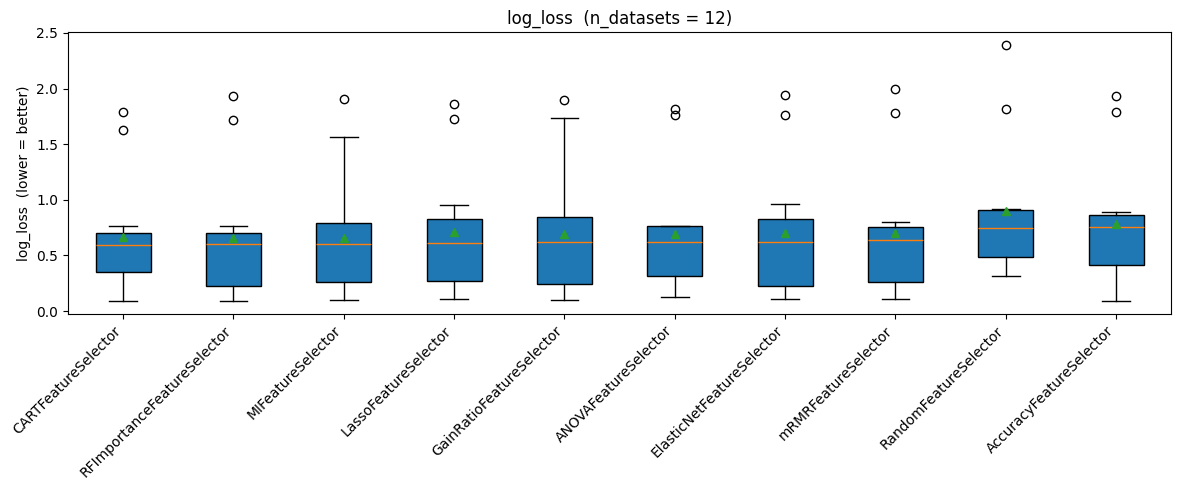

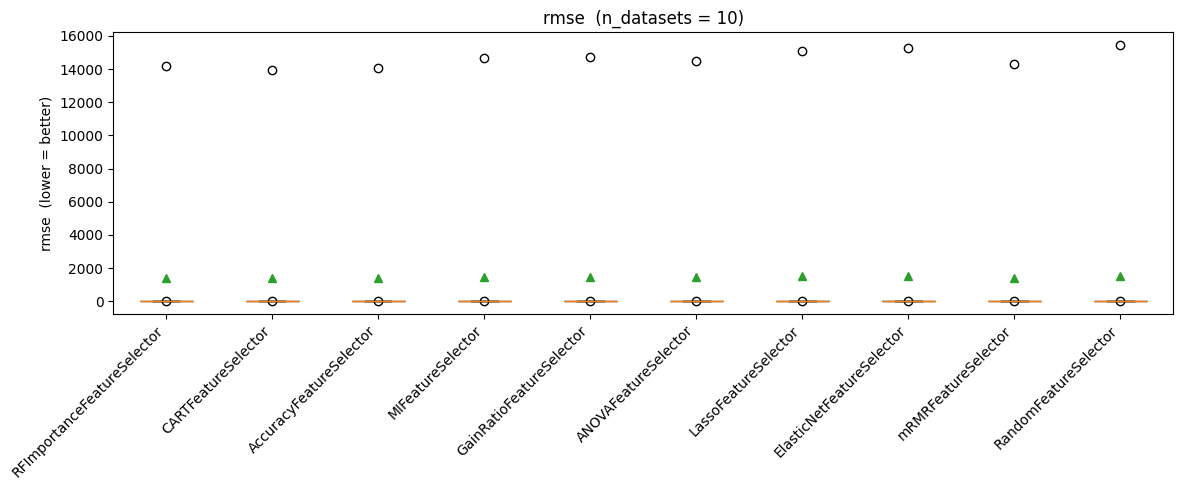

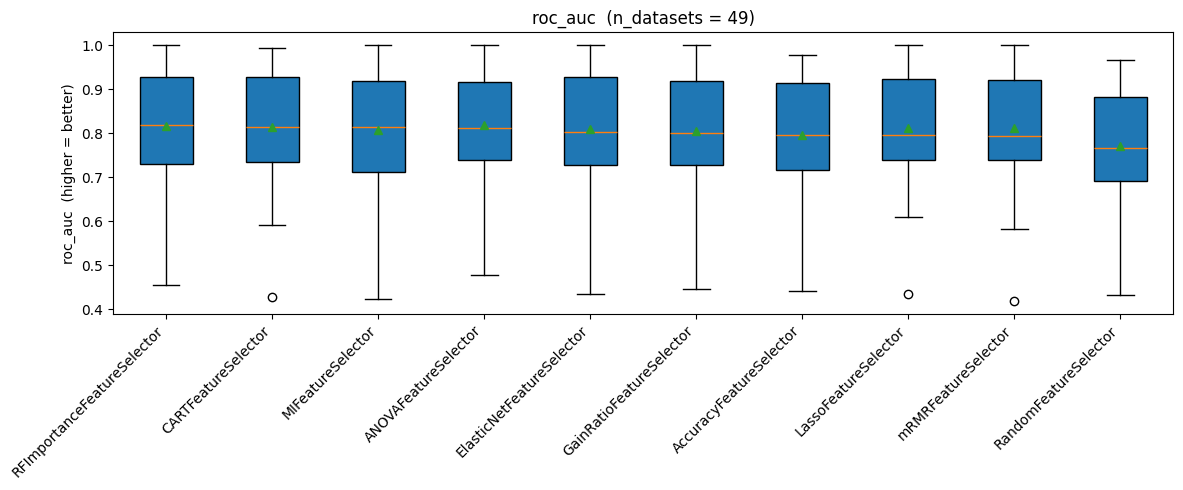

In [3]:

# ## 1. Per-metric performance
#
# Aggregate to one `metric_error` per `(dataset, method, metric)` by averaging
# over the remaining dimensions (`split_idx`, `budget_index`, ...). Then for
# each metric, boxplot the distribution across datasets, one box per FS
# method. Lower is better for every metric here.
 
# %%
# %%# %%
def to_plot_value(metric, errors):
    """Map the stored 'lower-is-better' metric_error back to its natural form."""
    if metric == "roc_auc":
        return 1.0 - errors
    return errors

def metric_ylabel(metric):
    if metric == "roc_auc":
        return "roc_auc  (higher = better)"
    return f"{metric}  (lower = better)"

perf = (
    df.groupby([METRIC_COL, DATASET_COL, METHOD_COL])[ERROR_COL]
      .mean()
      .reset_index()
)
metrics = sorted(perf[METRIC_COL].unique())
methods = sorted(perf[METHOD_COL].unique())
# %%
for m in metrics:
    sub = perf[perf[METRIC_COL] == m]

    # Order by median of metric_error (lower = better, always — keeps
    # 'leftmost = best' consistent across all three metric facets).
    method_order = (
        sub.groupby(METHOD_COL)[ERROR_COL]
           .median()
           .sort_values()
           .index
           .tolist()
    )
    data = [
        to_plot_value(m, sub.loc[sub[METHOD_COL] == method, ERROR_COL].to_numpy())
        for method in method_order
    ]

    fig, ax = plt.subplots(figsize=(max(6, 1.2 * len(method_order)), 5))
    ax.boxplot(data, tick_labels=method_order, showmeans=True, patch_artist=True)
    ax.set_title(f"{m}  (n_datasets = {sub[DATASET_COL].nunique()})")
    ax.set_ylabel(metric_ylabel(m))
    ax.tick_params(axis="x", rotation=45)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"performance_{m}.png", dpi=150)
    plt.show()

In [4]:
big_rmse = (
    df[(df["metric"] == "rmse") & (df["metric_error"] > 4)]
    .groupby(["tid"])["metric_error"]
    .agg(["min", "max", "mean", "count"])
    .sort_values("max", ascending=False)
)
print(big_rmse)

                    min           max          mean  count
tid                                                       
7493221688  8223.793122  19795.266622  14618.494175    150
8467603651     9.295643     22.593023     12.784627    150


In [5]:
EXCLUDE_DATASET_TIDS = [7493221688, ] # brazilian houses
                        # 8467603651]

df = pd.read_csv(RESULTS_FILE, low_memory=False)
df_excluded = df[df["tid"].isin(EXCLUDE_DATASET_TIDS)]


In [6]:
print(f"{len(df_excluded)} bad rmse rows across {df_excluded['tid'].nunique()} datasets")
print(df_excluded[[
    "tid","feature_selection_method", "metric_error", "metric_error_val",  "feature_selection_budget_index",
]].sort_values("metric_error", ascending=False).to_string(index=False))

240 bad rmse rows across 1 datasets
       tid              feature_selection_method  metric_error  metric_error_val  feature_selection_budget_index
7493221688                 RandomFeatureSelector  19795.266622      14457.553235                               0
7493221688            ConsistencyFeatureSelector  19795.266622      14457.553235                               0
7493221688                  LassoFeatureSelector  19715.066527      14313.210721                               0
7493221688             ElasticNetFeatureSelector  19715.066527      14313.210721                               0
7493221688                     MIFeatureSelector  19459.086966      13949.834448                               0
7493221688              GainRatioFeatureSelector  19459.086966      13949.834448                               0
7493221688                 RandomFeatureSelector  19458.206795      13979.626916                               1
7493221688            ConsistencyFeatureSelector  19458.2067

In [11]:
EXCLUDE_DATASET_TIDS = [8467603651] # sueprconductivity

df = pd.read_csv(RESULTS_FILE, low_memory=False)
df_excluded = df[df["tid"].isin(EXCLUDE_DATASET_TIDS)]
EXCLUDE_METHOD_SUBSTRINGS = [
    "disr",                    # DISRFeatureSelector
    "jmi",                     # JMIFeatureSelector
    "cmim",                    # CMIMFeatureSelector
    "symmetricaluncertainty",  # SymmetricalUncertaintyFeatureSelector
    "consistency",             # ConsistencyFeatureSelector
    "cfs",                     # CFSFeatureSelector — assumed from "cos"; remove or change if not
]

def _norm(s):
    return re.sub(r"[^a-z0-9]", "", str(s).lower())

excluded = sorted(
    m for m in df_excluded[METHOD_COL].unique()
    if any(sub in _norm(m) for sub in EXCLUDE_METHOD_SUBSTRINGS)
)
print(f"Excluding {len(excluded)} method(s): {excluded}")
df_excluded = df_excluded[~df_excluded[METHOD_COL].isin(excluded)].copy()
print(f"Remaining methods: {sorted(df[METHOD_COL].unique())}")

Excluding 6 method(s): ['CFSFeatureSelector', 'CMIMFeatureSelector', 'ConsistencyFeatureSelector', 'DISRFeatureSelector', 'JMIFeatureSelector', 'SymmetricalUncertaintyFeatureSelector']
Remaining methods: ['ANOVAFeatureSelector', 'AccuracyFeatureSelector', 'CARTFeatureSelector', 'CFSFeatureSelector', 'CMIMFeatureSelector', 'ConsistencyFeatureSelector', 'DISRFeatureSelector', 'ElasticNetFeatureSelector', 'GainRatioFeatureSelector', 'JMIFeatureSelector', 'LassoFeatureSelector', 'MIFeatureSelector', 'RFImportanceFeatureSelector', 'RandomFeatureSelector', 'SymmetricalUncertaintyFeatureSelector', 'mRMRFeatureSelector']


In [12]:
print(f"{len(df_excluded)} bad rmse rows across {df_excluded['tid'].nunique()} datasets")
print(df_excluded[[
    "tid","feature_selection_method", "metric_error", "metric_error_val",  "feature_selection_budget_index",
]].sort_values("metric_error", ascending=False).to_string(index=False))

150 bad rmse rows across 1 datasets
       tid    feature_selection_method  metric_error  metric_error_val  feature_selection_budget_index
8467603651         mRMRFeatureSelector     22.593023         22.382818                               0
8467603651     AccuracyFeatureSelector     21.627849         21.611251                               0
8467603651       RandomFeatureSelector     21.615105         21.633368                               0
8467603651         CARTFeatureSelector     21.466373         21.321233                               0
8467603651    GainRatioFeatureSelector     21.075124         20.921775                               0
8467603651           MIFeatureSelector     20.967702         21.047135                               0
8467603651        ANOVAFeatureSelector     20.910185         20.692358                               0
8467603651        LassoFeatureSelector     20.852718         20.989378                               0
8467603651 RFImportanceFeatureSelecto

In [13]:
df_one = df[(df["metric"] == "roc_auc") & (df["metric_error"] == 0)]
EXCLUDE_METHOD_SUBSTRINGS = [
    "disr",                    # DISRFeatureSelector
    "jmi",                     # JMIFeatureSelector
    "cmim",                    # CMIMFeatureSelector
    "symmetricaluncertainty",  # SymmetricalUncertaintyFeatureSelector
    "consistency",             # ConsistencyFeatureSelector
    "cfs",                     # CFSFeatureSelector — assumed from "cos"; remove or change if not
]

def _norm(s):
    return re.sub(r"[^a-z0-9]", "", str(s).lower())

excluded = sorted(
    m for m in df_one[METHOD_COL].unique()
    if any(sub in _norm(m) for sub in EXCLUDE_METHOD_SUBSTRINGS)
)
print(f"Excluding {len(excluded)} method(s): {excluded}")
df_one = df_one[~df_one[METHOD_COL].isin(excluded)].copy()
print(f"{len(df_one)} perfect-AUC rows across {df_one['tid'].nunique()} datasets")
print(df_one[[
    "tid", "feature_selection_method", "metric_error", "metric_error_val",
    "feature_selection_budget_index",
]].sort_values("feature_selection_budget_index").to_string(index=False))
df_one["tid"].unique()

Excluding 6 method(s): ['CFSFeatureSelector', 'CMIMFeatureSelector', 'ConsistencyFeatureSelector', 'DISRFeatureSelector', 'JMIFeatureSelector', 'SymmetricalUncertaintyFeatureSelector']
322 perfect-AUC rows across 4 datasets
       tid    feature_selection_method  metric_error  metric_error_val  feature_selection_budget_index
3294278573         mRMRFeatureSelector           0.0      0.000000e+00                               0
3294278573 RFImportanceFeatureSelector           0.0      4.743833e-02                               0
3294278573           MIFeatureSelector           0.0      3.795066e-03                               0
3294278573           MIFeatureSelector           0.0      0.000000e+00                               0
3294278573         mRMRFeatureSelector           0.0      0.000000e+00                               0
3294278573        ANOVAFeatureSelector           0.0      1.518027e-02                               0
3294278573        LassoFeatureSelector           0.0   

array([3294278573, 6789920400, 5047778267, 4532501802])

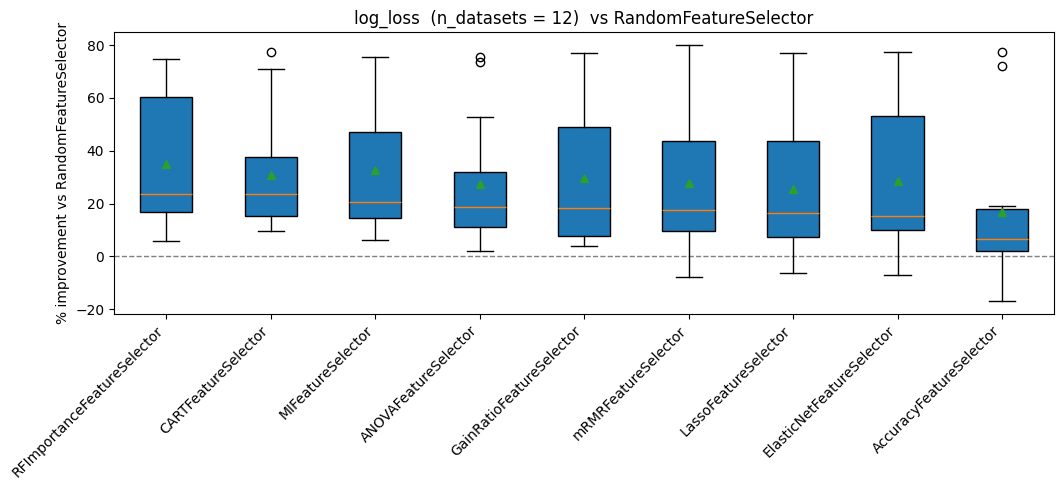

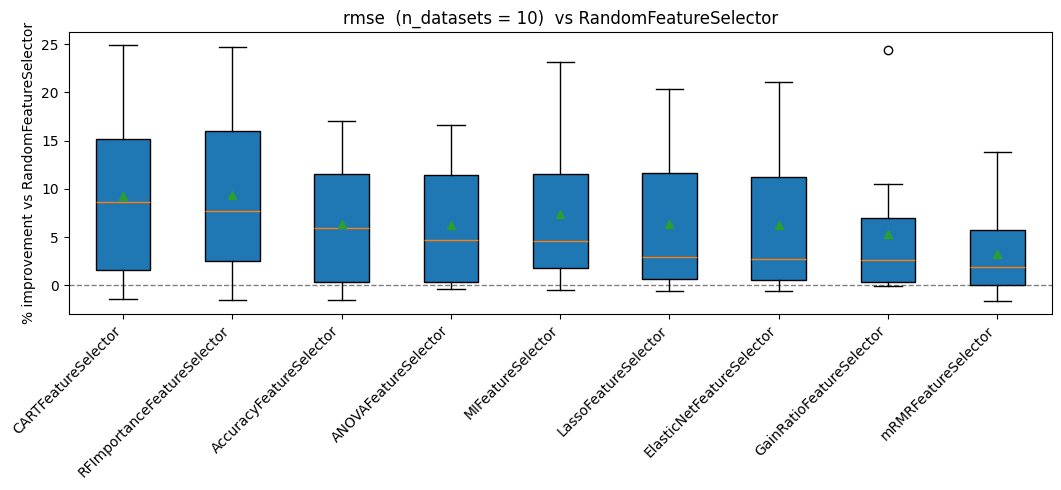

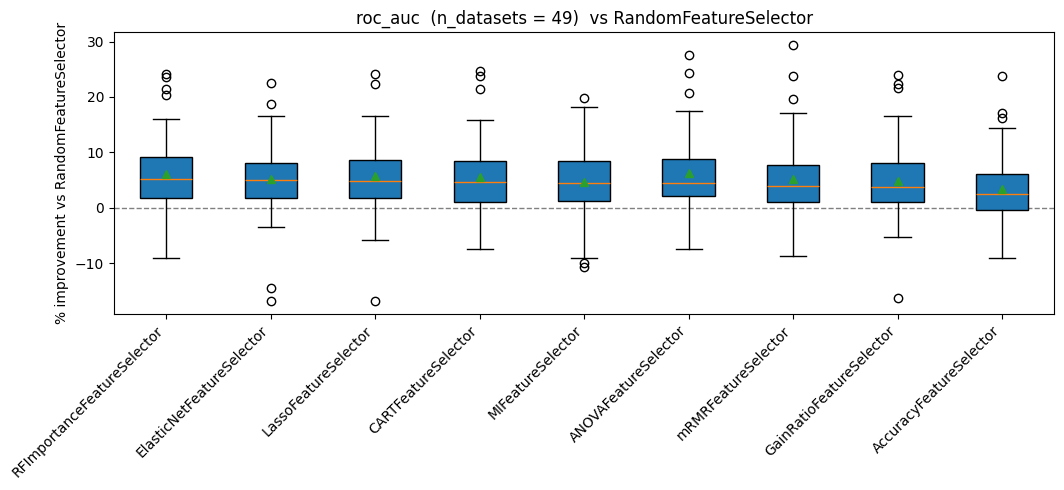

In [14]:
# %% [markdown]
# ## 1d. % improvement vs RandomFeatureSelector
#
# Per (dataset, method): compute the natural-direction relative improvement
# over the baseline on that same dataset. Dataset scale cancels, so we can
# pool across datasets within a metric.
#
#   - log_loss / rmse  (lower = better):  (baseline − method) / baseline
#   - roc_auc          (higher = better): (method − baseline) / baseline
#
# Both signs are chosen so positive = better than baseline. roc_auc datasets
# are evaluated in raw AUC space, not metric_error space.

# %%
def to_natural_score(metric, error_values):
    """metric_error is lower-is-better; flip back to raw roc_auc for that metric."""
    if metric == "roc_auc":
        return 1.0 - error_values
    return error_values

def is_higher_better(metric):
    return metric == "roc_auc"


# Natural scores in wide form: rows = (metric, dataset), cols = method
perf_n = perf.copy()
perf_n["score"] = [
    to_natural_score(m, e)
    for m, e in zip(perf_n[METRIC_COL], perf_n[ERROR_COL])
]
wide_natural = perf_n.pivot_table(
    index=[METRIC_COL, DATASET_COL],
    columns=METHOD_COL,
    values="score",
)

# Relative improvement vs baseline, sign per metric
rows = []
for (metric, ds), row in wide_natural.iterrows():
    base = row[BASELINE_METHOD]
    if pd.isna(base) or base == 0:
        continue
    rel = (row - base) / base if is_higher_better(metric) else (base - row) / base
    for method, val in rel.items():
        if method == BASELINE_METHOD or pd.isna(val):
            continue
        rows.append({
            METRIC_COL: metric,
            DATASET_COL: ds,
            METHOD_COL: method,
            "rel_improvement": val,
        })
improvement = pd.DataFrame(rows)

# Boxplot per metric, distribution across datasets
for m in sorted(improvement[METRIC_COL].unique()):
    sub = improvement[improvement[METRIC_COL] == m]

    method_order = (
        sub.groupby(METHOD_COL)["rel_improvement"]
           .median()
           .sort_values(ascending=False)   # best (highest improvement) first
           .index.tolist()
    )
    data = [
        sub.loc[sub[METHOD_COL] == method, "rel_improvement"].to_numpy() * 100
        for method in method_order
    ]

    fig, ax = plt.subplots(figsize=(max(6, 1.2 * len(method_order)), 5))
    ax.axhline(0, color="grey", linestyle="--", linewidth=1, zorder=0)
    ax.boxplot(data, tick_labels=method_order, showmeans=True, patch_artist=True)
    ax.set_title(f"{m}  (n_datasets = {sub[DATASET_COL].nunique()})"
                 f"  vs {BASELINE_METHOD}")
    ax.set_ylabel(f"% improvement vs {BASELINE_METHOD}")
    ax.tick_params(axis="x", rotation=45)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"performance_normalized_{m}.png", dpi=150)
    plt.show()